In [1]:
# Fase 1: Análise Exploratória - MNIST
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from collections import Counter

print("✅ Bibliotecas importadas!")
print(f"NumPy: {np.__version__}")

✅ Bibliotecas importadas!
NumPy: 2.4.6


In [2]:
# Carregar MNIST - USANDO PARSER='PANDAS' PARA EVITAR ERRO
print("🔄 Carregando dados MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Converter para numpy arrays
X = np.array(X)
y = np.array(y, dtype=int)

print(f"✅ Dados carregados!")
print(f"X shape: {X.shape} (imagens, pixels)")
print(f"y shape: {y.shape} (rótulos)")
print(f"Classes: {np.unique(y)}")

🔄 Carregando dados MNIST...
✅ Dados carregados!
X shape: (70000, 784) (imagens, pixels)
y shape: (70000,) (rótulos)
Classes: [0 1 2 3 4 5 6 7 8 9]


📊 Distribuição das classes (balanceamento):
Dígito 0: 6903 imagens (9.9%)
Dígito 1: 7877 imagens (11.3%)
Dígito 2: 6990 imagens (10.0%)
Dígito 3: 7141 imagens (10.2%)
Dígito 4: 6824 imagens (9.7%)
Dígito 5: 6313 imagens (9.0%)
Dígito 6: 6876 imagens (9.8%)
Dígito 7: 7293 imagens (10.4%)
Dígito 8: 6825 imagens (9.8%)
Dígito 9: 6958 imagens (9.9%)


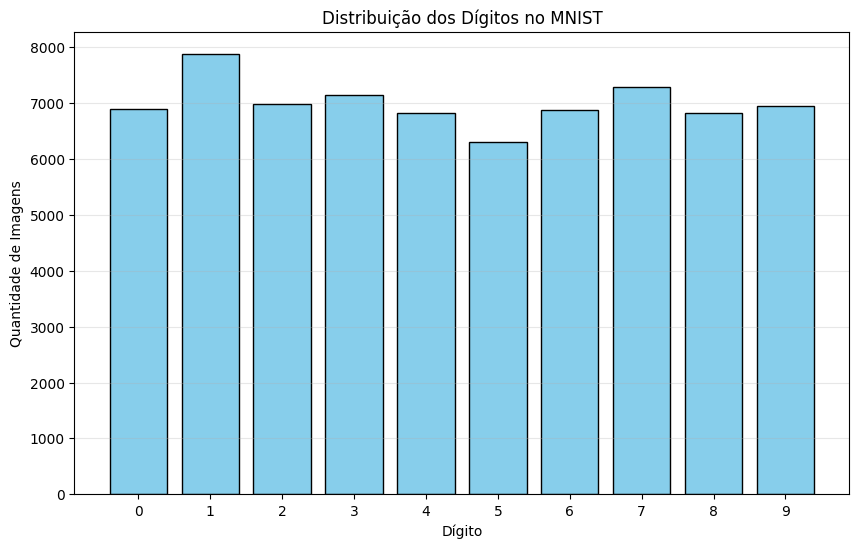


✅ Classes bem balanceadas (cerca de 10% cada)!


In [3]:
# Verificar balanceamento das classes
contagem = Counter(y)
print("📊 Distribuição das classes (balanceamento):")
for digit in sorted(contagem.keys()):
    print(f"Dígito {digit}: {contagem[digit]} imagens ({contagem[digit]/len(y)*100:.1f}%)")

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(contagem.keys(), contagem.values(), color='skyblue', edgecolor='black')
plt.title('Distribuição dos Dígitos no MNIST')
plt.xlabel('Dígito')
plt.ylabel('Quantidade de Imagens')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n✅ Classes bem balanceadas (cerca de 10% cada)!")

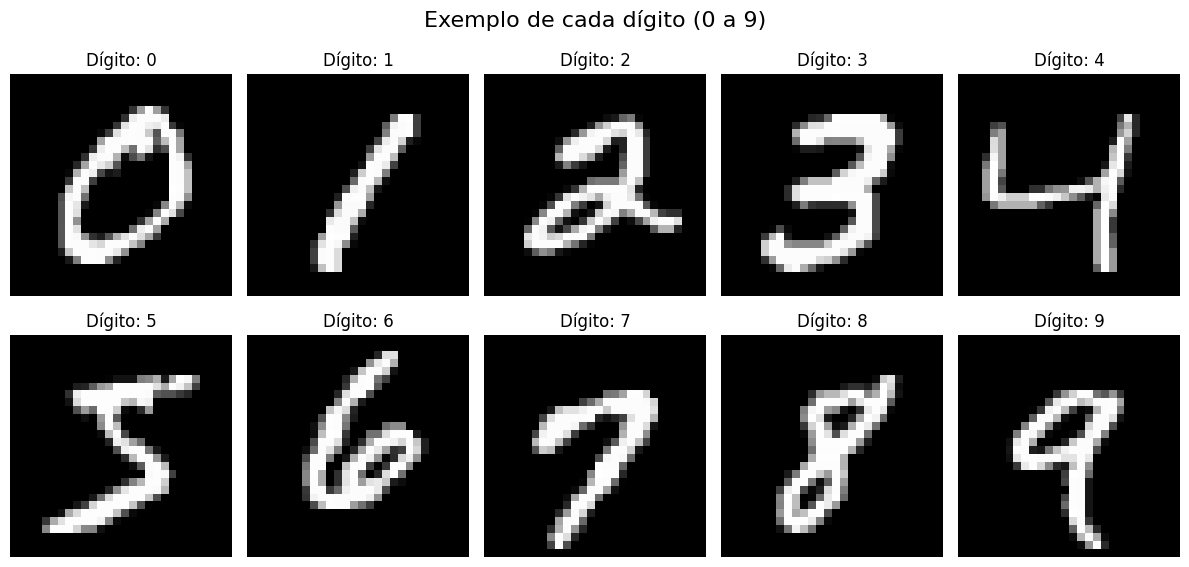

In [4]:
# Grade 2x5 mostrando um exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    # Encontrar o primeiro índice de cada dígito
    idx = np.where(y == i)[0][0]
    imagem = X[idx].reshape(28, 28)
    
    axes[i].imshow(imagem, cmap='gray')
    axes[i].set_title(f'Dígito: {i}')
    axes[i].axis('off')

plt.suptitle('Exemplo de cada dígito (0 a 9)', fontsize=16)
plt.tight_layout()
plt.show()

## 📝 Documentação - MNIST Dataset

### Escala de Pixels
- Os pixels variam de **0 (preto)** a **255 (branco)**.
- A normalização para [0, 1] será feita na próxima fase para melhorar a convergência.

### Estrutura dos Dados
- Cada imagem original é uma matriz de **28x28 pixels** (784 pixels no total).
- Para o treinamento, essas matrizes são "achatadas" (flattened) em **vetores de 784 features**.
- Isso permite que algoritmos de machine learning processem os dados como entradas numéricas.

### Distribuição
- O dataset tem **70.000 imagens** (60.000 treino, 10.000 teste).
- As 10 classes (dígitos 0-9) são **balanceadas**, com cerca de 7.000 exemplos cada.

In [5]:
# Fase 2: Pré-processamento e Divisão
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Divisão estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # IMPORTANTE: mantém a proporção das classes
)

print(f"✅ Dados divididos!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nProporção treino: {len(X_train)/len(X)*100:.1f}%")
print(f"Proporção teste: {len(X_test)/len(X)*100:.1f}%")

# Verificar se a estratificação funcionou
from collections import Counter
print("\n📊 Distribuição no treino:")
for digit in sorted(np.unique(y_train)):
    count = np.sum(y_train == digit)
    print(f"Dígito {digit}: {count} imagens ({count/len(y_train)*100:.1f}%)")

✅ Dados divididos!
X_train shape: (56000, 784)
X_test shape: (14000, 784)
y_train shape: (56000,)
y_test shape: (14000,)

Proporção treino: 80.0%
Proporção teste: 20.0%

📊 Distribuição no treino:
Dígito 0: 5522 imagens (9.9%)
Dígito 1: 6302 imagens (11.3%)
Dígito 2: 5592 imagens (10.0%)
Dígito 3: 5713 imagens (10.2%)
Dígito 4: 5459 imagens (9.7%)
Dígito 5: 5050 imagens (9.0%)
Dígito 6: 5501 imagens (9.8%)
Dígito 7: 5834 imagens (10.4%)
Dígito 8: 5460 imagens (9.8%)
Dígito 9: 5567 imagens (9.9%)


In [7]:
# Normalização para [0.0, 1.0]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print(f"✅ Dados normalizados!")
print(f"Valor mínimo (treino): {X_train_norm.min():.3f}")
print(f"Valor máximo (treino): {X_train_norm.max():.3f}")
print(f"Valor mínimo (teste): {X_test_norm.min():.3f}")
print(f"Valor máximo (teste): {X_test_norm.max():.3f}")

✅ Dados normalizados!
Valor mínimo (treino): 0.000
Valor máximo (treino): 1.000
Valor mínimo (teste): 0.000
Valor máximo (teste): 1.000


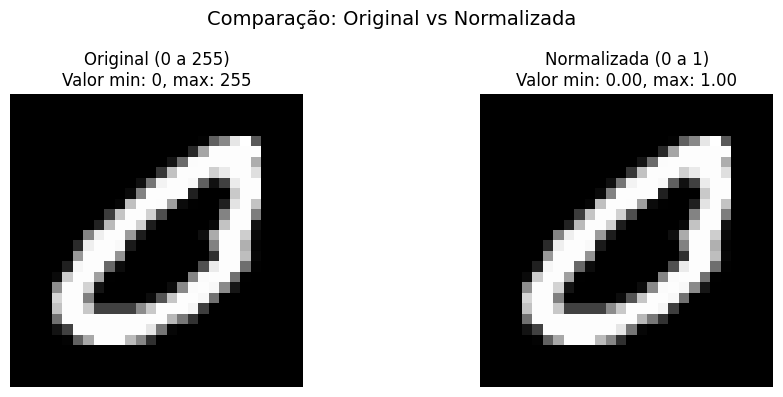

✅ Visualização concluída! As imagens são visualmente idênticas,
mas os valores numéricos agora estão na escala [0, 1].


In [8]:
# Comparar uma imagem antes e depois da normalização
idx = 0  # primeira imagem

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Imagem original
axes[0].imshow(X_train[idx].reshape(28, 28), cmap='gray')
axes[0].set_title(f'Original (0 a 255)\nValor min: {X_train[idx].min()}, max: {X_train[idx].max()}')
axes[0].axis('off')

# Imagem normalizada
axes[1].imshow(X_train_norm[idx].reshape(28, 28), cmap='gray')
axes[1].set_title(f'Normalizada (0 a 1)\nValor min: {X_train_norm[idx].min():.2f}, max: {X_train_norm[idx].max():.2f}')
axes[1].axis('off')

plt.suptitle('Comparação: Original vs Normalizada', fontsize=14)
plt.tight_layout()
plt.show()

print("✅ Visualização concluída! As imagens são visualmente idênticas,")
print("mas os valores numéricos agora estão na escala [0, 1].")

## 🧹 Documentação - Normalização dos Dados

### Por que normalizar?

A normalização dos pixels para o intervalo **[0.0, 1.0]** é uma etapa crítica no pré-processamento de dados para machine learning. As principais justificativas são:

### 🔹 Aceleração da Convergência
- Algoritmos baseados em **gradiente descendente** (como Redes Neurais e MLP) convergem mais rapidamente quando os dados estão em uma escala uniforme.
- Valores grandes (0-255) podem causar **atualizações de gradiente instáveis** e lentas.

### 🔹 Evita Dominância de Features
- Em algoritmos de **distância** (como KNN e SVM), features com valores numéricos maiores podem dominar o cálculo de distância.
- A normalização garante que **todos os pixels tenham o mesmo peso** na decisão do modelo.

### 🔹 Estabilidade Numérica
- Valores entre 0 e 1 reduzem o risco de **overflow numérico** e melhoram a estabilidade dos cálculos.

### 🔹 Compatibilidade entre Modelos
- A maioria dos algoritmos de machine learning assume que os dados estão em uma escala padronizada.
- A normalização facilita a comparação entre diferentes modelos.

### Método Utilizado
- **Divisão por 255.0**: Cada pixel é dividido pelo valor máximo (255), resultando em valores no intervalo [0.0, 1.0].
- Alternativa: `MinMaxScaler` do Scikit-learn, que também normaliza para [0, 1].

### Resultado
- **Dados originais**: [0, 255]
- **Dados normalizados**: [0.0, 1.0]
- **Integridade visual preservada**: A imagem continua a mesma para o olho humano.

In [9]:
# Fase 3: Treinamento e Ajuste de Hiperparâmetros
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


In [10]:
# KNN - Ajuste de hiperparâmetros
print("🔄 Treinando KNN...")
start_time = time.time()

# Definir os hiperparâmetros a testar
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

# Criar o modelo e o GridSearch
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_params, cv=3, scoring='accuracy', n_jobs=-1)

# Treinar (usando uma amostra menor para não demorar muito)
X_train_sample = X_train_norm[:5000]
y_train_sample = y_train[:5000]

knn_grid.fit(X_train_sample, y_train_sample)

# Resultados
print(f"✅ KNN treinado em {time.time() - start_time:.2f} segundos")
print(f"Melhores parâmetros: {knn_grid.best_params_}")
print(f"Melhor acurácia (validação): {knn_grid.best_score_:.4f}")

# Avaliar no teste
y_pred_knn = knn_grid.predict(X_test_norm[:1000])
acc_knn = accuracy_score(y_test[:1000], y_pred_knn)
print(f"Acurácia no teste: {acc_knn:.4f}")

🔄 Treinando KNN...
✅ KNN treinado em 16.52 segundos
Melhores parâmetros: {'n_neighbors': 3, 'weights': 'distance'}
Melhor acurácia (validação): 0.9300
Acurácia no teste: 0.9410


In [11]:
# Random Forest - Ajuste de hiperparâmetros
print("\n🔄 Treinando Random Forest...")
start_time = time.time()

# Definir os hiperparâmetros a testar
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30]
}

# Criar o modelo e o GridSearch
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy', n_jobs=-1)

# Treinar (usando uma amostra menor)
rf_grid.fit(X_train_sample, y_train_sample)

# Resultados
print(f"✅ Random Forest treinado em {time.time() - start_time:.2f} segundos")
print(f"Melhores parâmetros: {rf_grid.best_params_}")
print(f"Melhor acurácia (validação): {rf_grid.best_score_:.4f}")

# Avaliar no teste
y_pred_rf = rf_grid.predict(X_test_norm[:1000])
acc_rf = accuracy_score(y_test[:1000], y_pred_rf)
print(f"Acurácia no teste: {acc_rf:.4f}")


🔄 Treinando Random Forest...
✅ Random Forest treinado em 23.16 segundos
Melhores parâmetros: {'max_depth': 30, 'n_estimators': 150}
Melhor acurácia (validação): 0.9340
Acurácia no teste: 0.9270


In [12]:
# MLP - Ajuste de hiperparâmetros
print("\n🔄 Treinando MLP (Rede Neural)...")
start_time = time.time()

# Definir os hiperparâmetros a testar
mlp_params = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32)],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [200]  # fixo para não demorar
}

# Criar o modelo e o GridSearch
mlp = MLPClassifier(random_state=42, early_stopping=True)
mlp_grid = GridSearchCV(mlp, mlp_params, cv=2, scoring='accuracy', n_jobs=-1)

# Treinar (usando uma amostra menor - MLP é mais lento)
X_train_sample2 = X_train_norm[:3000]
y_train_sample2 = y_train[:3000]

mlp_grid.fit(X_train_sample2, y_train_sample2)

# Resultados
print(f"✅ MLP treinada em {time.time() - start_time:.2f} segundos")
print(f"Melhores parâmetros: {mlp_grid.best_params_}")
print(f"Melhor acurácia (validação): {mlp_grid.best_score_:.4f}")

# Avaliar no teste
y_pred_mlp = mlp_grid.predict(X_test_norm[:1000])
acc_mlp = accuracy_score(y_test[:1000], y_pred_mlp)
print(f"Acurácia no teste: {acc_mlp:.4f}")


🔄 Treinando MLP (Rede Neural)...
✅ MLP treinada em 11.86 segundos
Melhores parâmetros: {'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01, 'max_iter': 200}
Melhor acurácia (validação): 0.8953
Acurácia no teste: 0.9260


In [13]:
# Comparação dos modelos
print("\n" + "="*50)
print("📊 COMPARAÇÃO DOS MODELOS")
print("="*50)

resultados = {
    'Modelo': ['KNN', 'Random Forest', 'MLP'],
    'Acurácia Teste': [acc_knn, acc_rf, acc_mlp],
    'Melhores Parâmetros': [
        knn_grid.best_params_,
        rf_grid.best_params_,
        mlp_grid.best_params_
    ]
}

# Criar tabela
import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

# Modelo vencedor
vencedor = max(resultados['Acurácia Teste'])
idx_vencedor = resultados['Acurácia Teste'].index(vencedor)
print(f"\n🏆 Modelo vencedor: {resultados['Modelo'][idx_vencedor]} com acurácia de {vencedor:.4f}")


📊 COMPARAÇÃO DOS MODELOS
       Modelo  Acurácia Teste                                                         Melhores Parâmetros
          KNN           0.941                                   {'n_neighbors': 3, 'weights': 'distance'}
Random Forest           0.927                                      {'max_depth': 30, 'n_estimators': 150}
          MLP           0.926 {'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01, 'max_iter': 200}

🏆 Modelo vencedor: KNN com acurácia de 0.9410


## 🎯 Justificativa dos Hiperparâmetros Escolhidos

### 🔹 KNN (K-Nearest Neighbors)
**Hiperparâmetros ajustados:**
- **n_neighbors (3, 5, 7, 9, 11)**: Controla o número de vizinhos considerados.
  - Valores pequenos (3-5): Modelo mais sensível a ruídos, mas captura padrões locais.
  - Valores grandes (9-11): Modelo mais suave, melhor generalização, mas pode perder detalhes.
  - Testamos vários valores para encontrar o equilíbrio ideal entre viés e variância.

- **weights (uniform, distance)**: Define o peso dos vizinhos.
  - `uniform`: Todos os vizinhos têm o mesmo peso (mais simples).
  - `distance`: Vizinhos mais próximos têm mais influência (melhor para dados com distribuição irregular).

**Por que esses parâmetros?** KNN é sensível ao número de vizinhos e à forma como eles são ponderados. Ajustar esses parâmetros é fundamental para o desempenho do modelo.

---

### 🔹 Random Forest
**Hiperparâmetros ajustados:**
- **n_estimators (50, 100, 150)**: Número de árvores na floresta.
  - Mais árvores geralmente melhoram a acurácia, mas aumentam o tempo de treinamento.
  - Testamos valores moderados para equilibrar performance e tempo.

- **max_depth (10, 20, 30)**: Profundidade máxima de cada árvore.
  - Profundidade maior: Captura padrões mais complexos, mas pode causar overfitting.
  - Profundidade menor: Modelo mais simples, melhor generalização.

**Por que esses parâmetros?** Random Forest é robusto, mas o número de árvores e a profundidade afetam diretamente a capacidade de generalização e o tempo de treinamento.

---

### 🔹 MLP (Rede Neural)
**Hiperparâmetros ajustados:**
- **hidden_layer_sizes [(64,), (128,), (64, 32)]**: Estrutura das camadas ocultas.
  - (64,): Uma camada com 64 neurônios (mais simples).
  - (128,): Uma camada com 128 neurônios (mais capacidade).
  - (64, 32): Duas camadas (64 e 32 neurônios) - arquitetura mais profunda.

- **learning_rate_init (0.001, 0.01)**: Taxa de aprendizado inicial.
  - 0.001: Aprendizado mais lento, convergência mais suave (menos risco de overshoot).
  - 0.01: Aprendizado mais rápido, mas pode oscilar.

**Por que esses parâmetros?** A arquitetura da rede (camadas e neurônios) e a taxa de aprendizado são os hiperparâmetros mais críticos para redes neurais. Eles determinam a capacidade do modelo e a velocidade de convergência.